# CPU inference testing

{'prompt_results': [{'prompt_index': 0, 'echo': {'prompt_index': 0, 'type': 'text', 'text': 'bedroom', 'num_boxes': 0}, 'predictions': [{'masks': [[[1945, 444], [1945, 451], [1945, 449], [1946, 448], [1946, 446], [1945, 445]], [[1978, 322], [1977, 323], [1975, 323], [1974, 324], [1973, 324], [1971, 326], [1970, 326], [1965, 331], [1965, 338], [1964, 339], [1964, 342], [1963, 343], [1963, 348], [1964, 349], [1964, 350], [1963, 351], [1963, 371], [1964, 372], [1964, 387], [1963, 388], [1963, 393], [1962, 394], [1962, 412], [1961, 413], [1961, 415], [1960, 416], [1960, 417], [1961, 418], [1961, 420], [1962, 421], [1962, 424], [1961, 425], [1961, 431], [1960, 432], [1960, 437], [1961, 438], [1961, 441], [1962, 442], [1962, 467], [1960, 469], [1960, 470], [1958, 472], [1955, 472], [1954, 473], [1944, 473], [1943, 474], [1942, 474], [1941, 475], [1940, 475], [1938, 477], [1938, 478], [1937, 479], [1937, 481], [1936, 482], [1936, 483], [1935, 484], [1935, 485], [1931, 489], [1930, 489], [1929

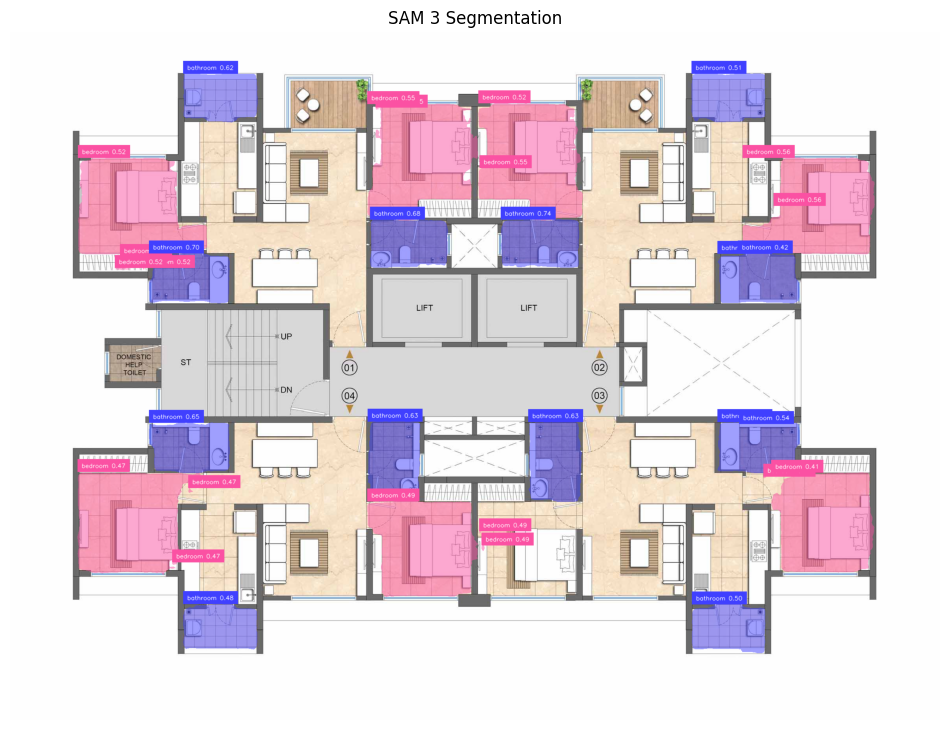

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
import requests
import base64

API_KEY = "qNXfdB49GG9sICdVeSJA"
image_path = "/content/page23_img76.png"

image_bgr = cv2.imread(image_path)
_, buffer = cv2.imencode('.jpg', image_bgr)
image_base64 = base64.b64encode(buffer).decode('utf-8')

payload = {
    "image": {"type": "base64", "value": image_base64},
    "prompts": [
        {"type": "text", "text": "bedroom"},
        {"type": "text", "text": "bathroom"}
    ],
    "output_prob_thresh": 0.4,
    "format": "polygon"
}

url = f"https://serverless.roboflow.com/sam3/concept_segment?api_key={API_KEY}"
response = requests.post(url, json=payload)
data = response.json()

# Debug: print the full response to see what came back
print(data)

# Safely check for prompt_results before proceeding
if "prompt_results" not in data:
    print("Error: 'prompt_results' not in response.")
    print("Full response:", data)
else:
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    h, w = image_rgb.shape[:2]

    masks, xyxy, confidences, class_ids, labels = [], [], [], [], []
    prompt_to_class = {}
    next_class_id = 0

    for prompt_result in data["prompt_results"]:
        prompt_text = prompt_result["echo"]["text"]

        if prompt_text not in prompt_to_class:
            prompt_to_class[prompt_text] = next_class_id
            next_class_id += 1

        class_id = prompt_to_class[prompt_text]

        for prediction in prompt_result["predictions"]:
            confidence = float(prediction["confidence"])

            for polygon in prediction["masks"]:
                polygon = np.array(polygon, dtype=np.int32)

                if polygon.ndim != 2 or polygon.shape[0] < 3:
                    continue

                mask = np.zeros((h, w), dtype=np.uint8)
                cv2.fillPoly(mask, [polygon], 1)

                x_min, y_min = polygon[:, 0].min(), polygon[:, 1].min()
                x_max, y_max = polygon[:, 0].max(), polygon[:, 1].max()

                masks.append(mask.astype(bool))
                xyxy.append([x_min, y_min, x_max, y_max])
                confidences.append(confidence)
                class_ids.append(class_id)
                labels.append(f"{prompt_text} {confidence:.2f}")

    detections = sv.Detections(
        xyxy=np.array(xyxy, dtype=np.float32),
        mask=np.array(masks, dtype=bool),
        confidence=np.array(confidences, dtype=np.float32),
        class_id=np.array(class_ids, dtype=int),
        data={"labels": np.array(labels, dtype=object)}
    )

    mask_annotator = sv.MaskAnnotator()
    label_annotator = sv.LabelAnnotator(text_position=sv.Position.TOP_LEFT)

    annotated = image_rgb.copy()
    annotated = mask_annotator.annotate(scene=annotated, detections=detections)
    annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

    plt.figure(figsize=(12, 12))
    plt.imshow(annotated)
    plt.axis("off")
    plt.title("SAM 3 Segmentation")
    plt.show()

    cv2.imwrite("segmented_output.png", cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))